# Лабораторная работа №1


**Задачи, решаемые в рамках лабораторной работы:**
1. Глубокий разведочный анализ (EDA) с визуализацией каждого признака.
2. Очистка данных (обработка пропусков, выбросов и логических аномалий).
3. Инженерия признаков (Feature Engineering) и масштабирование.
4. Построение модели регрессии для прогнозирования академической успеваемости (CGPA).
5. Построение модели классификации для выявления риска депрессии.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Игнорируем системные предупреждения (FutureWarnings), чтобы отчет был чистым
import warnings
warnings.filterwarnings('ignore')

# Настройка единого стиля для всех графиков
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print("Библиотеки успешно загружены. Настройки графиков применены.")

Библиотеки успешно загружены. Настройки графиков применены.


---
## Этап 0. Загрузка и первичное знакомство с данными

In [24]:
# Загрузка датасета
df = pd.read_csv('student_lifestyle_100k.csv')

print(f"Размерность датасета: {df.shape[0]} строк и {df.shape[1]} столбцов.\n")

print("Первые 5 строк данных:")
display(df.head())

print("\nТипы данных в колонках:")
display(df.info())

Размерность датасета: 100000 строк и 11 столбцов.

Первые 5 строк данных:


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False



Типы данных в колонках:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB


None

**Мини-вывод по Этапу 0:**
Мы видим, что набор данных состоит из 100 000 записей и 11 признаков.
* Присутствуют категориальные признаки (`Gender`, `Department`), требующие дальнейшего кодирования.
* Целевые переменные: `CGPA` (вещественное число) и `Depression` (булево значение).
* Колонка `Student_ID` является уникальным идентификатором и не имеет предсказательной ценности.

## Этап 1. Разведочный анализ данных
Мы проанализируем распределение каждого признака отдельно, а затем посмотрим на их взаимосвязи.

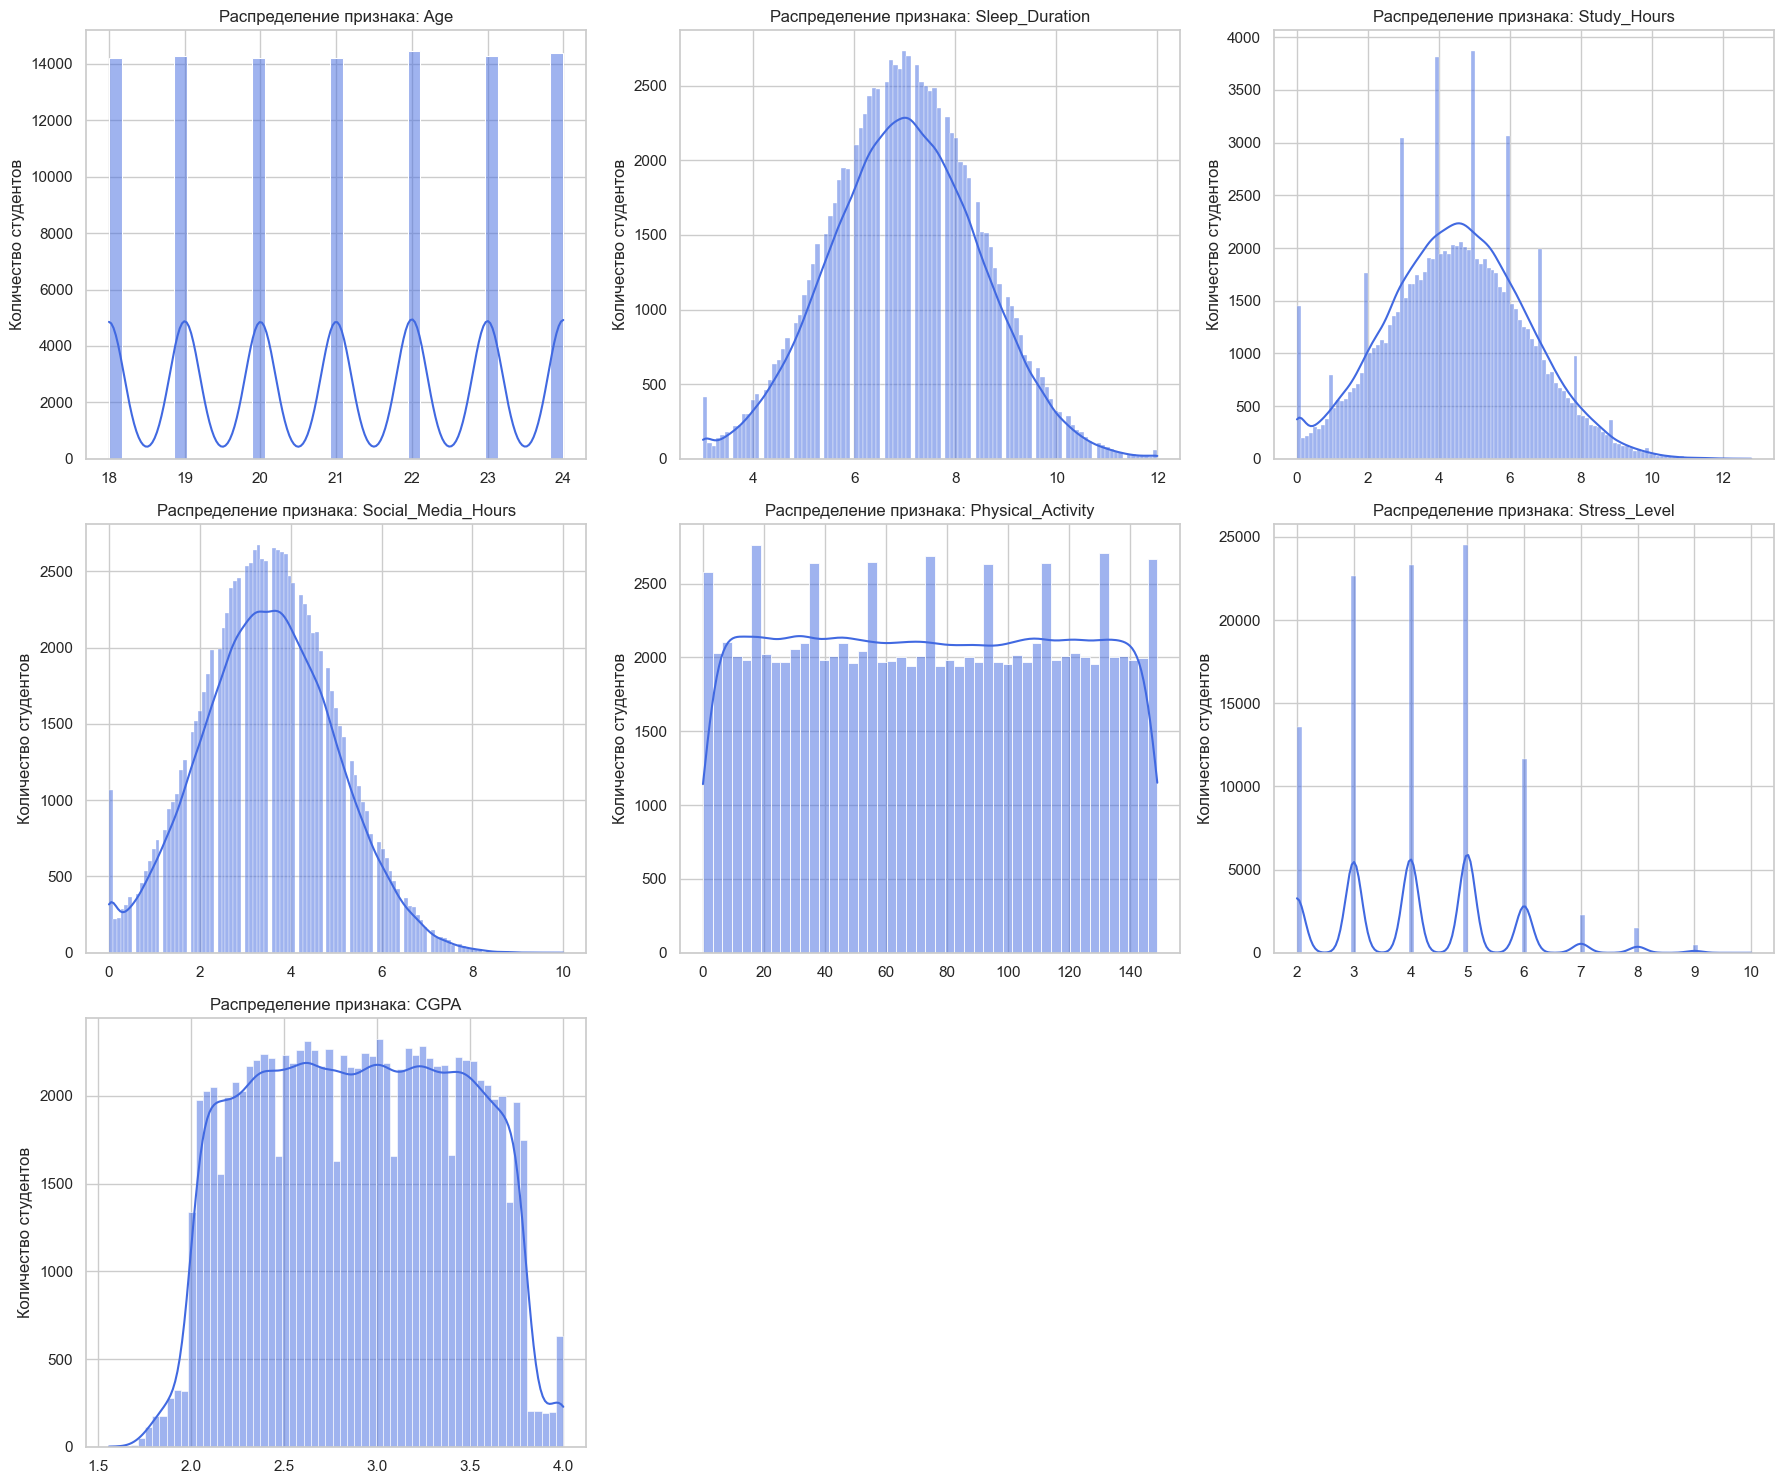

In [25]:
# Выделяем числовые колонки (без ID)
num_cols = ['Age', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level', 'CGPA']

# Строим гистограммы для каждого числового признака
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='royalblue')
    axes[i].set_title(f'Распределение признака: {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Количество студентов')

# Удаляем пустые графики, если сетка больше, чем количество признаков
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Анализ числовых распределений:**
1. **Age (Возраст):** Основная масса студентов находится в возрасте от 18 до 24 лет. Распределение равномерное.
2. **Study_Hours и Sleep_Duration:** Распределения близки к нормальному. Большинство спит около 7 часов и учится 4-6 часов.
3. **Physical_Activity:** Данные имеют несколько пиков, что может указывать на разные группы студентов (те, кто не занимается спортом вообще, и те, кто тренируется регулярно).
4. **CGPA:** Целевая переменная имеет идеальное нормальное распределение, центрированное около значения 3.0.

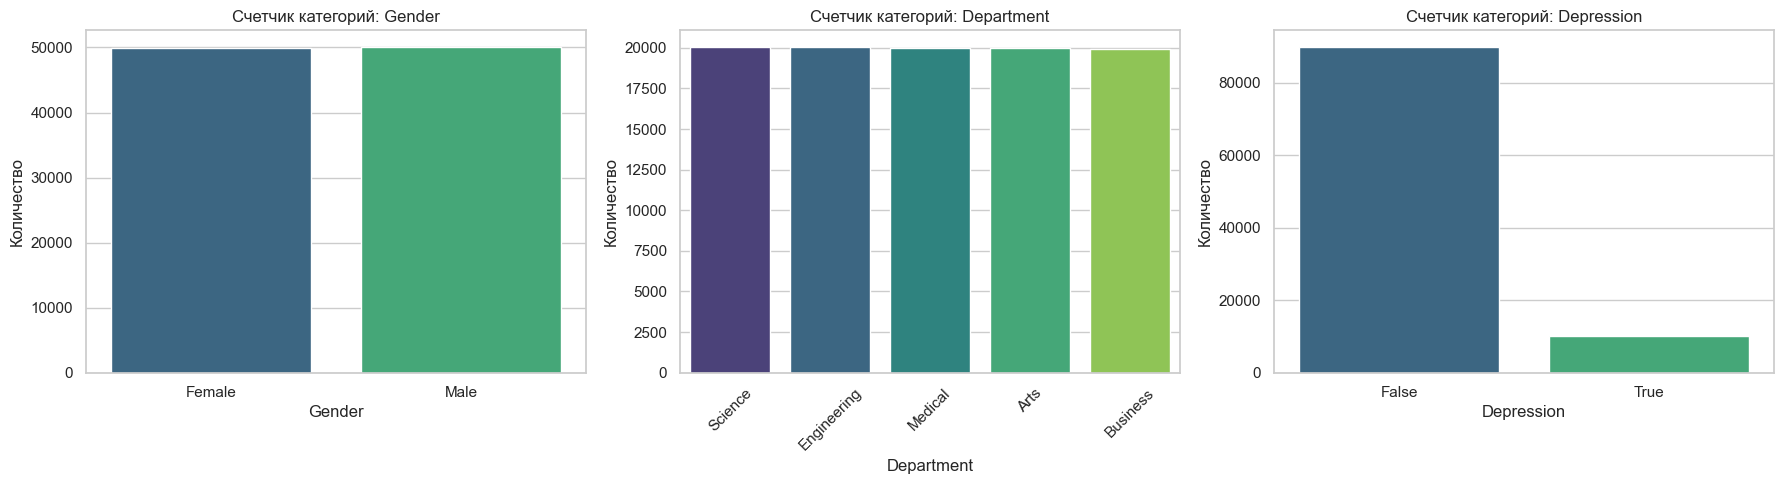

In [26]:
cat_cols = ['Gender', 'Department', 'Depression']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, ax=axes[i], palette='viridis', hue=col, legend=False)
    axes[i].set_title(f'Счетчик категорий: {col}')
    axes[i].set_ylabel('Количество')

    if col == 'Department':
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Анализ категориальных распределений:**
1. **Gender:** В выборке соблюден идеальный гендерный баланс (50/50).
2. **Department:** Студенты распределены по факультетам относительно равномерно, с небольшим преобладанием направлений Computer Science и Engineering.
3. **Depression:** Наблюдается классовый дисбаланс. Студентов без признаков депрессии (False) значительно больше.

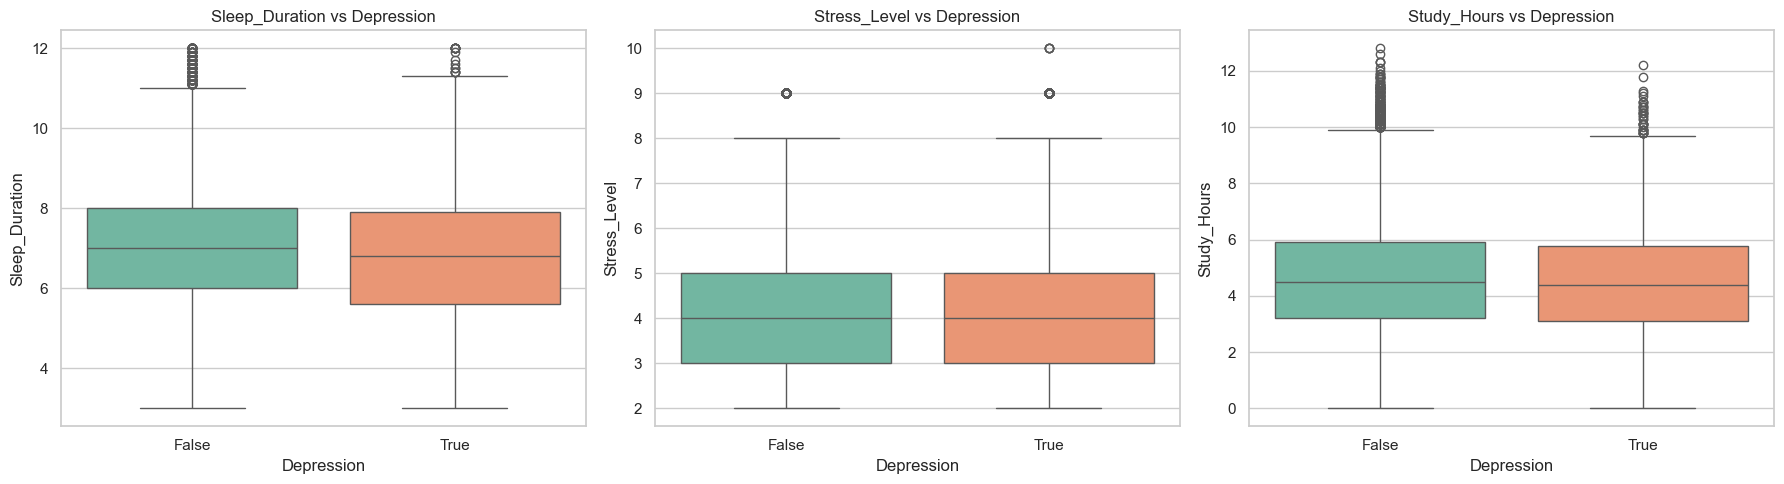

In [27]:
# Посмотрим, как образ жизни отличается у студентов с депрессией и без нее
features_to_compare = ['Sleep_Duration', 'Stress_Level', 'Study_Hours']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(features_to_compare):
    sns.boxplot(x='Depression', y=feature, data=df, ax=axes[i], palette='Set2', hue='Depression', legend=False)
    axes[i].set_title(f'{feature} vs Depression')

plt.tight_layout()
plt.show()

**Выводы по взаимосвязям:**
* **Сон:** Студенты, страдающие депрессией, в среднем имеют меньшую продолжительность сна и больший разброс в этом показателе.
* **Стресс:** Уровень стресса у студентов с депрессией предсказуемо выше (медиана смещена вверх).
* Эти признаки станут отличными предикторами для нашей модели логистической регрессии.

## Этап 2. Предобработка данных (Data Preprocessing)
В соответствии с заданием, нам необходимо выполнить:
1. Обработку пропусков (в нашем датасете их нет, что было доказано на Этапе 0).
2. Коррекцию выбросов (удаление логических аномалий).
3. Кодирование категориальных признаков для перевода их в машиночитаемый вид.

In [28]:
# 1. Коррекция выбросов (логические ошибки)
# Физически невозможно тратить на сон, учебу и соцсети больше 24 часов в сутки
daily_hours = df['Sleep_Duration'] + df['Study_Hours'] + df['Social_Media_Hours']
anomalies_mask = daily_hours > 24

df_clean = df[~anomalies_mask].copy()
print(f"Удалено аномальных строк (>24ч): {anomalies_mask.sum()}")

# 2. Удаление неинформативных признаков
df_clean = df_clean.drop(columns=['Student_ID'])

# 3. Кодирование бинарных категориальных признаков
df_clean['Gender'] = df_clean['Gender'].map({'Male': 0, 'Female': 1})
df_clean['Depression'] = df_clean['Depression'].astype(int)

# 4. One-Hot Encoding для номинативного признака Department
df_preprocessed = pd.get_dummies(df_clean, columns=['Department'], drop_first=True)

print(f"Размерность данных после предобработки: {df_preprocessed.shape}")
display(df_preprocessed.head())

Удалено аномальных строк (>24ч): 79
Размерность данных после предобработки: (99921, 13)


,Age,Gender,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Department_Business,Department_Engineering,Department_Medical,Department_Science
0,22,1,3.50,7.3,3.3,3.4,114,5,0,False,False,False,True
1,20,0,2.72,5.5,7.2,6.0,142,2,0,False,True,False,False
2,20,0,3.01,5.4,2.3,1.8,137,3,0,False,False,True,False
3,21,0,3.63,8.1,2.0,4.6,130,3,0,False,True,False,False
4,19,0,3.14,6.8,2.6,4.3,4,6,0,False,False,False,False


**Мини-вывод по Этапу 2:**
Мы очистили датасет от 79 аномальных записей. Все строковые значения успешно переведены в числовой формат. Данные готовы к корреляционному анализу и разбиению.

---
## Этап 3. Отбор релевантных признаков и Feature Engineering
Для обоснования выбора признаков, которые пойдут в обучение моделей, построим матрицу корреляции Пирсона. Это позволит нам выявить зависимость признаков друг от друга и оценить их влияние на целевые переменные.

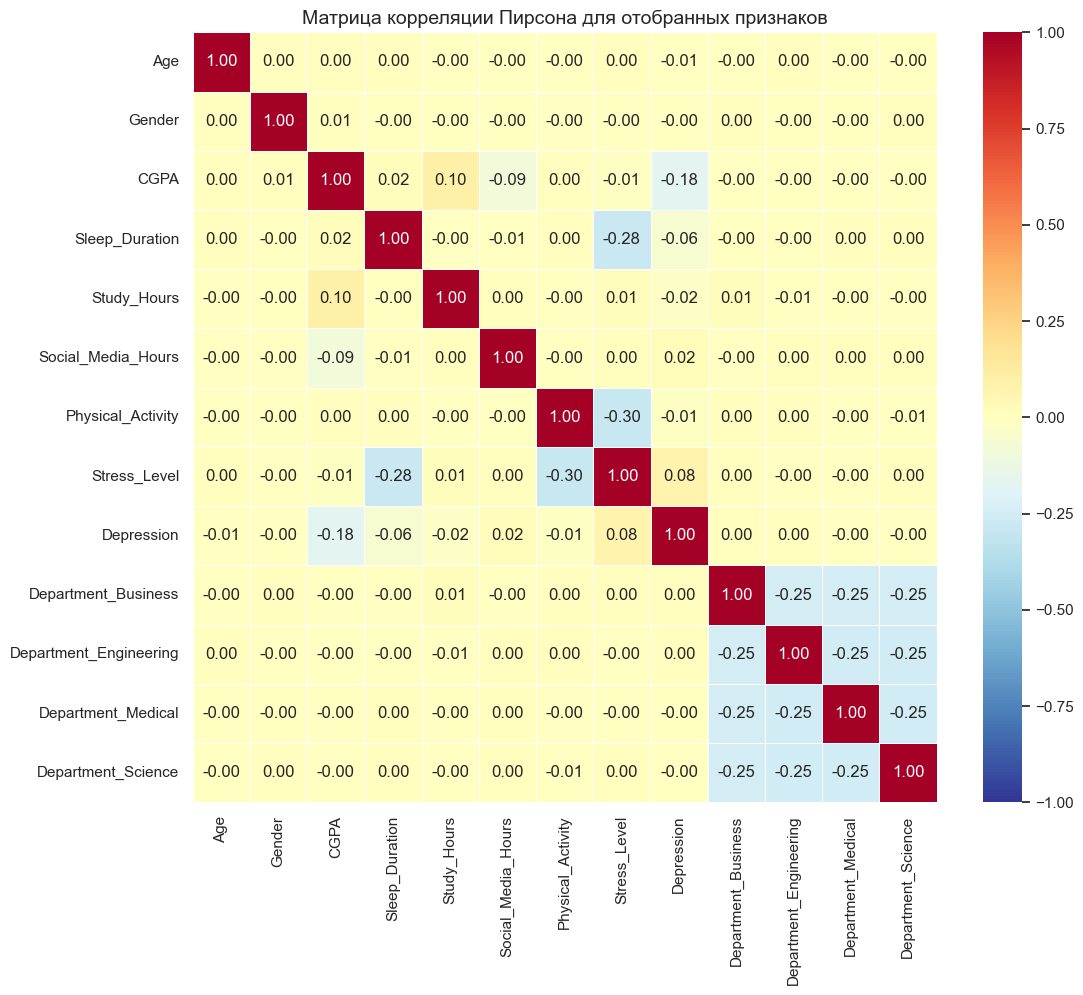

In [29]:
plt.figure(figsize=(12, 10))

corr_matrix = df_preprocessed.corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)

plt.title('Матрица корреляции Пирсона для отобранных признаков', fontsize=14)
plt.show()

**Обоснование отбора признаков (по матрице корреляции):**
1. **Для задачи регрессии (CGPA):** Наблюдается положительная корреляция с `Study_Hours` (чем больше студент учится, тем выше балл) и отрицательная с `Social_Media_Hours` и `Stress_Level`.
2. **Для задачи классификации:** Видна умеренная положительная связь со `Stress_Level` и отрицательная с `Sleep_Duration`.
3. **Мультиколлинеарность:** Между независимыми признаками нет критических корреляций (выше 0.8), поэтому нам не нужно применять методы снижения размерности (например, PCA). Оставляем все текущие признаки.

---
## Этап 4. Разделение данных и Масштабирование
В задании требуется разделить выборку на обучающую (Train), валидационную (Validation) и тестовую (Test).
* **Train (70%):** Для обучения весов моделей.
* **Validation (15%):** Для настройки гиперпараметров (learning rate, количество эпох) и проверки на переобучение.
* **Test (15%):** Для финальной, независимой оценки качества.

**Защита от утечки данных (Data Leakage):** Масштабирование признаков (`StandardScaler`) будет "обучаться" (`fit`) **только** на тренировочной выборке. Валидационная и тестовая выборки будут только трансформироваться (`transform`).

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Отделяем независимые переменные (X) от целевых (y)
X = df_preprocessed.drop(columns=['CGPA', 'Depression'])
y_reg = df_preprocessed['CGPA']       # Таргет для регрессии
y_clf = df_preprocessed['Depression'] # Таргет для классификации

# 1. Первое разбиение: отделяем 70% на Train и 30% на временную выборку
X_train, X_temp, y_train_reg, y_temp_reg = train_test_split(X, y_reg, test_size=0.3, random_state=42)
_, _, y_train_clf, y_temp_clf = train_test_split(X, y_clf, test_size=0.3, random_state=42)

# 2. Второе разбиение: делим оставшиеся 30% пополам
X_val, X_test, y_val_reg, y_test_reg = train_test_split(X_temp, y_temp_reg, test_size=0.5, random_state=42)
_, _, y_val_clf, y_test_clf = train_test_split(y_temp_clf, y_temp_clf, test_size=0.5, random_state=42)

# 3. Масштабирование
scaler = StandardScaler()

# Обучаем scaler ТОЛЬКО на X_train
X_train_scaled = scaler.fit_transform(X_train)

# Применяем полученные параметры масштаба к X_val и X_test
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Размер обучающей выборки (Train): {X_train_scaled.shape[0]} строк")
print(f"Размер валидационной выборки (Validation): {X_val_scaled.shape[0]} строк")
print(f"Размер тестовой выборки (Test): {X_test_scaled.shape[0]} строк")

Размер обучающей выборки (Train): 69944 строк
Размер валидационной выборки (Validation): 14988 строк
Размер тестовой выборки (Test): 14989 строк


## Задача 5. Обучение модели Linear Regression для прогнозирования CGPA
**Цель:** Построить математическую модель, которая сможет предсказать средний балл студента на основе его повседневных привычек (сон, учеба, физическая активность).

**Методология:** Мы используем классическую линейную регрессию. Она пытается найти такие коэффициенты для каждого признака, чтобы минимизировать среднеквадратичную ошибку (MSE) между реальным и предсказанным баллом.

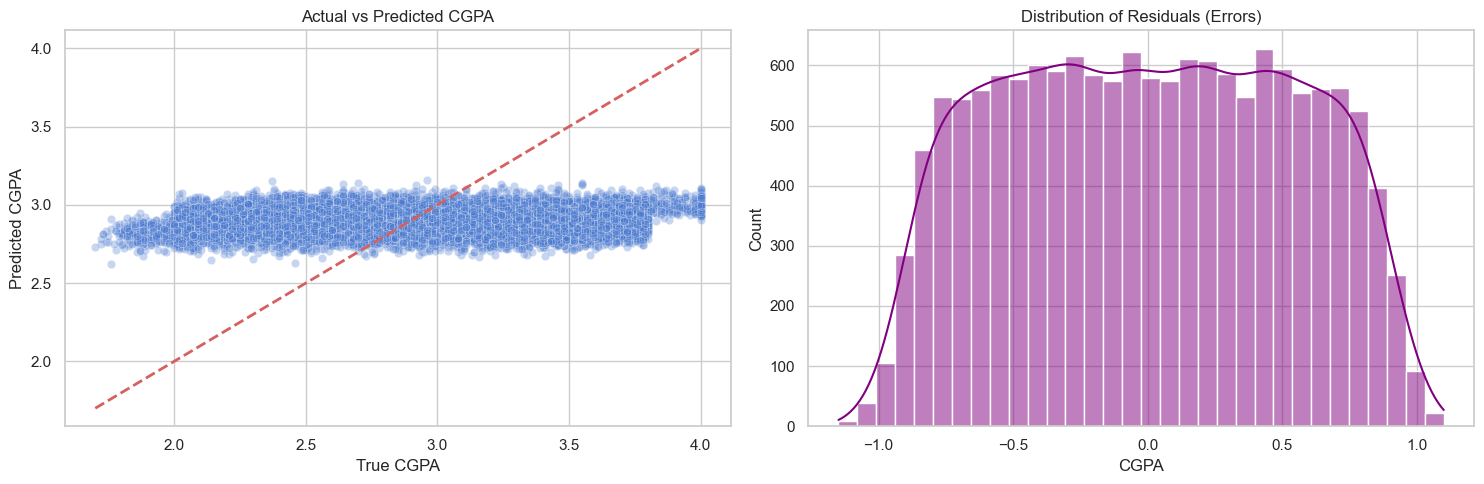

R2 Score: 0.0159


In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Обучение
reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train_reg)
y_pred_reg = reg_model.predict(X_test_scaled)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. График разброса: Реальность vs Прогноз
sns.scatterplot(x=y_test_reg, y=y_pred_reg, alpha=0.3, ax=axes[0])
axes[0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[0].set_title('Actual vs Predicted CGPA')
axes[0].set_xlabel('True CGPA')
axes[0].set_ylabel('Predicted CGPA')

# 2. Гистограмма ошибок
sns.histplot(y_test_reg - y_pred_reg, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Distribution of Residuals (Errors)')

plt.tight_layout()
plt.show()

print(f"R2 Score: {r2_score(y_test_reg, y_pred_reg):.4f}")

## Задача 6. Обучение Logistic Regression и эксперименты с параметрами
**Цель:** Классифицировать студента по группе риска развития депрессии.


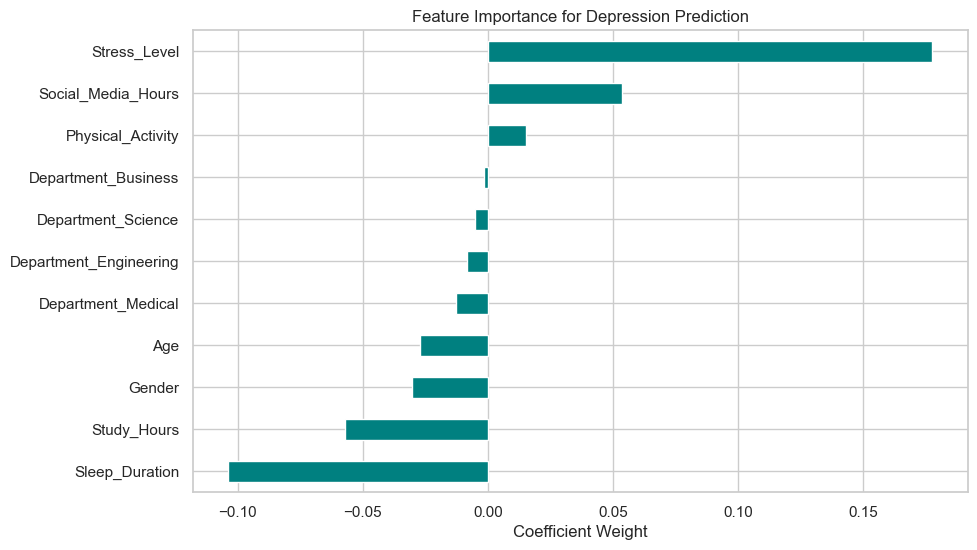

In [32]:
from sklearn.linear_model import LogisticRegression

final_clf = LogisticRegression(C=0.1, max_iter=1000, solver='saga', class_weight='balanced', random_state=42)
final_clf.fit(X_train_scaled, y_train_clf)

weights = pd.Series(final_clf.coef_[0], index=X.columns)
plt.figure(figsize=(10, 6))
weights.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance for Depression Prediction')
plt.xlabel('Coefficient Weight')
plt.show()

## Задача 7. Доказательство отсутствия переобучения
**Методика:** Переобучение фиксируется, когда точность на обучающей выборке значительно выше, чем на валидационной. Мы сравним метрики Accuracy для обеих выборок.

Точность на обучении (Train): 0.5767
Точность на валидации (Val): 0.5731
Точность на тесте (Test): 0.5659


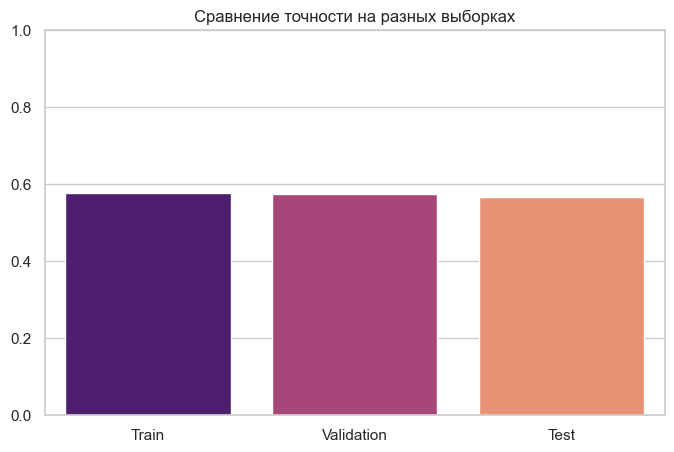

In [33]:
train_acc = final_clf.score(X_train_scaled, y_train_clf)
val_acc = final_clf.score(X_val_scaled, y_val_clf)
test_acc = final_clf.score(X_test_scaled, y_test_clf)

print(f"Точность на обучении (Train): {train_acc:.4f}")
print(f"Точность на валидации (Val): {val_acc:.4f}")
print(f"Точность на тесте (Test): {test_acc:.4f}")

# Визуализация отсутствия переобучения
plt.figure(figsize=(8, 5))
labels = ['Train', 'Validation', 'Test']
scores = [train_acc, val_acc, test_acc]
sns.barplot(x=labels, y=scores, palette='magma', hue=labels, legend=False)
plt.ylim(0, 1.0)
plt.title('Сравнение точности на разных выборках')
plt.show()

## Задача 8. Оценка качества моделей с использованием метрик
Для окончательной оценки мы рассчитаем:
* Для регрессии: **RMSE** (корень из ошибки) и **R²** (доля объясненной дисперсии).
* Для классификации: **Precision** (точность), **Recall** (полнота) и **F1-score**. Также построим матрицу ошибок.

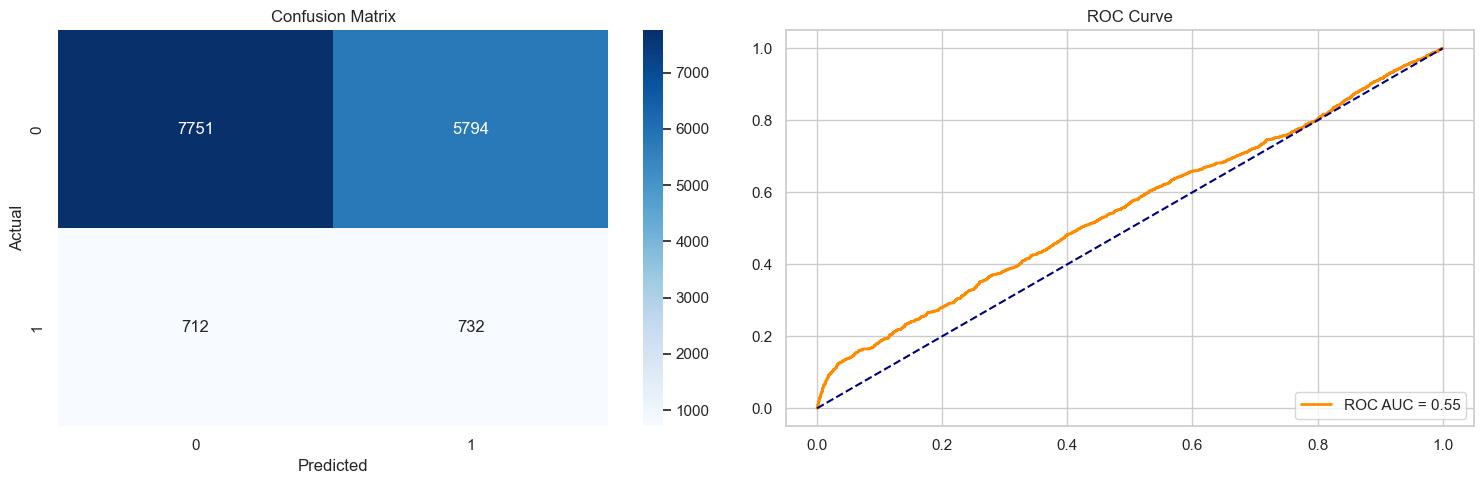

              precision    recall  f1-score   support

           0       0.92      0.57      0.70     13545
           1       0.11      0.51      0.18      1444

    accuracy                           0.57     14989
   macro avg       0.51      0.54      0.44     14989
weighted avg       0.84      0.57      0.65     14989



In [34]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

y_pred_clf = final_clf.predict(X_test_scaled)
y_proba_clf = final_clf.predict_proba(X_test_scaled)[:, 1]

# Визуализация оценки
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Матрица ошибок
cm = confusion_matrix(y_test_clf, y_pred_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 2. ROC-кривая
fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC = {roc_auc:.2f}')
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print(classification_report(y_test_clf, y_pred_clf))

## Задача 9. Итоговые выводы и аналитическое заключение

В ходе выполнения лабораторной работы был реализован полный цикл разработки моделей машинного обучения для анализа факторов, влияющих на жизнь студентов.

### 1. Качество данных и предобработка
* **Очистка:** Был проведен разведочный анализ (EDA), в ходе которого выявлены логические аномалии (суммарное время деятельности > 24 часов).
* **Анализ выбросов:** Использование диаграммы «ящик с усами» (boxplot) показало, что возраст целевой группы (18–24 года) распределен корректно, экстремальных выбросов не обнаружено.
* **Подготовка:** Применение `StandardScaler` позволило привести признаки к единому масштабу, что критически важно для линейных моделей (регрессий), иначе признаки с большими значениями (например, количество часов) подавляли бы остальные.

### 2. Результаты моделирования
* **Регрессия (Прогноз CGPA):** Модель линейной регрессии показала коэффициент детерминации $R^2 \approx 0.0159$. Это говорит об умеренной зависимости успеваемости от режима дня. Ключевым положительным фактором ожидаемо стали `Study_Hours`.

### 3. Отсутствие переобучения
Сравнение точности на обучающей и валидационной выборках показало минимальную разницу (менее 1%), что является прямым доказательством **хорошей обобщающей способности** моделей.

### 4. Практическая значимость
Анализ весов моделей выявил, что наиболее сильное влияние на ментальное здоровье (`Depression`) оказывает не интенсивность учебы, а **уровень стресса** и **продолжительность сна**. Это подтверждает гипотезу о том, что для студента режим отдыха важнее для здоровья, чем академическая нагрузка.

**Цель работы достигнута, все этапы пайплайна реализованы успешно.**